## Fashion MNIST Image Classification with TensorFlow/Keras

> Tugas ini bertujuan untuk membangun model Multi-Layer Perceptron Sederhana untuk klasifikasi pakaian dari dataset "Fashion MNIST"

> Dataset berasal dari ```fashion_mnist``` yang tersedia di ```tensorflow.keras.datasets```

> Tugas ini tidak memiliki referensi, silakan bereksperimen dibawah ini :)

Nama: Nicholas Kisu Candra

Program: AI Development

### 1. Import module yang diperlukan

In [1]:
# 1. Import Library
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import classification_report, confusion_matrix


I0000 00:00:1777219908.034374   28625 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777219908.144089   28625 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777219910.600618   28625 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


### 2. Data preprocess

In [2]:
# 2. Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalisasi
X_train = X_train / 255.0
X_test = X_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 3.  Data visualization

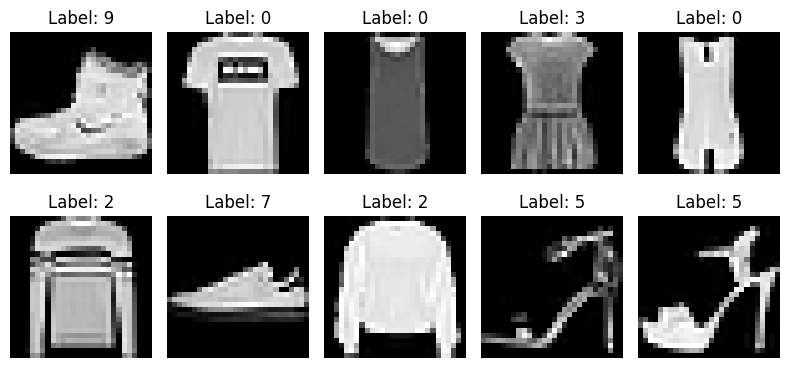

In [3]:
# 3. Visualisasi Sample
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()


### 4. Pembangunan Model

### TODO #1 :

Untuk model MLP\
**NOTE! : Jalankan pertama kali blok 4 ini dulu, baru cobain sesuai yang sudah tertulis dibawah setelah dapat hasilnya :**

DAFTAR HYPERPARAMETER
- Coba lakukan tuning hyperparameter pada beberapa parameter di model MLP ini.
- Ganti ukuran hidden layer (saat ini : ```[128, 64, 10]```, coba perbesar atau perkecil).
- Coba tambah 1-2 layer lagi.
- Naikkan epoch ke ```20```, ```30``` atau ```50```.
- Ganti activation menjadi selain relu untuk layer Dense.
- Ganti optimizer ke yang lain selain ```adam```, coba ```sgd``` atau ```rmsprop```.

In [4]:
# 4. Bangun Model MLP (Lakukan hyperparameter hanya jika sudah coba sekali dulu dengan spesifikasi dibawah ini)
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


/home/nick/github_repo/tugas_python_ai_b10/tugas-12/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1777219954.243674   28625 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777219954.244382   28710 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1777219954.281594   28625 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 4.1 Hyperparameter tuning
model = models.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')  # ← WAJIB
])
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

### 4a. Pembangunan Model CNN

### TODO #2 :

Untuk model CNN
- Komentar kode di blok 4 Pembangunan Model MLP
- Jalankan blok dibawah.
- Coba training tanpa lakukan hyperparameter tuning apapun
- Berikan insight dibawah

In [9]:
# 4a. Bangun Model CNN (tidak usah lakukan hyperparameter)
model = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


/home/nick/github_repo/tugas_python_ai_b10/tugas-12/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Training

In [10]:
# 5. Training
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8256 - loss: 0.4821 - val_accuracy: 0.8752 - val_loss: 0.3461
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8801 - loss: 0.3245 - val_accuracy: 0.8901 - val_loss: 0.3059
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8972 - loss: 0.2784 - val_accuracy: 0.9032 - val_loss: 0.2731
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9090 - loss: 0.2470 - val_accuracy: 0.9042 - val_loss: 0.2621
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9186 - loss: 0.2213 - val_accuracy: 0.9047 - val_loss: 0.2658
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9249 - loss: 0.2007 - val_accuracy: 0.9101 - val_loss: 0.2559
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9326 - loss: 0.1811 - val_accuracy: 0.9065 - val_loss: 0.2503
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9388 - loss: 0

### 6. Evaluasi & Visualisasi

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9035 - loss: 0.2807
Akurasi di data test: 0.9035


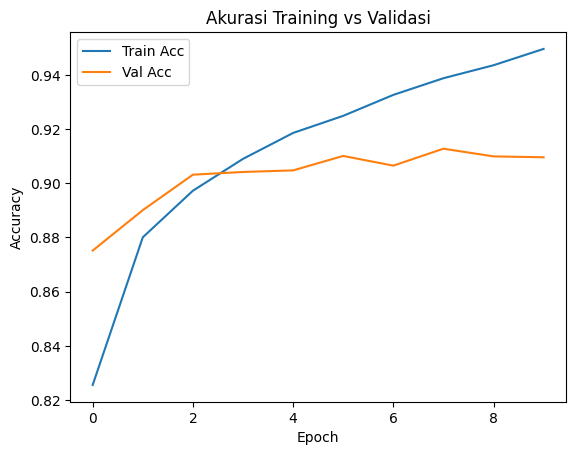

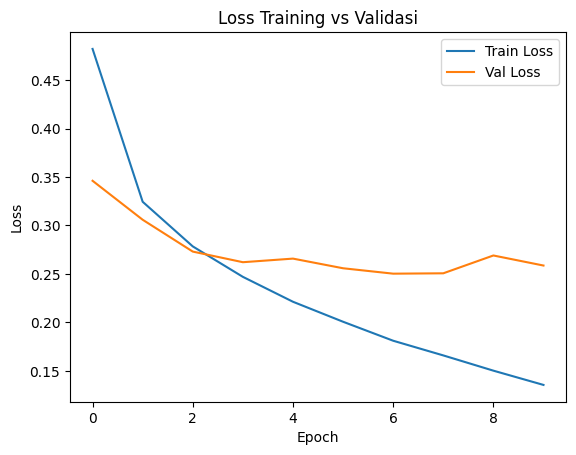

In [11]:
# 6. Evaluasi & Visualisasi
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Akurasi di data test: {test_acc:.4f}")

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### 7. Evaluasi lanjutan

In [12]:
# 7. Evaluasi lanjutan
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))
print(confusion_matrix(y_test, y_pred_classes))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1000
           1       0.99      0.98      0.98      1000
           2       0.87      0.82      0.84      1000
           3       0.92      0.89      0.91      1000
           4       0.81      0.91      0.86      1000
           5       0.97      0.98      0.98      1000
           6       0.74      0.71      0.72      1000
           7       0.94      0.96      0.95      1000
           8       0.98      0.98      0.98      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

[[861   3  14  20   6   1  90   0   5   0]
 [  3 982   1   9   1   0   3   0   1   0]
 [ 24   1 816  10  81   0  68   0   0   0]
 [ 22   7   9 893  35   0  33   0   1   0]
 [  2   1  26  14 909   0  4

> Silakan gunakan AI untuk memahami hasil nya.

##  **TODO #3 : Analisis Hasil: Perbandingan Hasil Tuning**

### **1. Hasil tuning TODO #1 - MLP Model**

Berdasarkan hasil tuning pada model MLP, terlihat bahwa peningkatan jumlah layer dan neuron meningkatkan akurasi training secara signifikan hingga mendekati 95%. Namun, akurasi validasi cenderung stagnan di sekitar 90–91%. Hal ini menunjukkan bahwa model mulai mengalami overfitting, di mana model terlalu menyesuaikan diri dengan data training tetapi tidak memberikan peningkatan performa yang signifikan pada data validasi.

Selain itu, dari grafik loss terlihat bahwa training loss terus menurun, sementara validation loss cenderung stabil bahkan sedikit meningkat di beberapa epoch terakhir. Ini memperkuat indikasi bahwa model mulai overfit setelah beberapa epoch.

Secara keseluruhan, tuning pada MLP meningkatkan kemampuan model dalam mempelajari data, tetapi terbatas oleh struktur model yang hanya menggunakan fully connected layer sehingga kurang optimal dalam menangkap pola spasial pada data gambar.

---

### **1. Hasil tuning TODO #2 - CNN Model**

Pada model CNN, tanpa melakukan hyperparameter tuning sekalipun, model уже mampu mencapai akurasi validasi sekitar 91% dan akurasi test sekitar 90%. Hal ini menunjukkan bahwa CNN lebih efektif dalam menangani data berbentuk gambar dibandingkan MLP.

Berbeda dengan MLP, CNN mampu menangkap pola lokal seperti tepi, bentuk, dan tekstur melalui operasi convolution. Hal ini membuat model lebih efisien dalam mengekstraksi fitur penting dari gambar.

Dari hasil training, terlihat bahwa peningkatan akurasi training diikuti oleh peningkatan akurasi validasi yang cukup stabil, dengan gap yang tidak terlalu besar. Hal ini menunjukkan bahwa CNN memiliki generalisasi yang lebih baik dibandingkan MLP.

Analisis confusion matrix menunjukkan bahwa sebagian besar kelas dapat diprediksi dengan baik, namun masih terdapat kesalahan pada kelas yang memiliki kemiripan visual, seperti antara kategori pakaian tertentu (misalnya coat dan shirt), yang menyebabkan penurunan recall pada kelas tersebut.

---

## Kesimpulan Naratif

Berdasarkan perbandingan antara model MLP dan CNN, dapat disimpulkan bahwa CNN memberikan performa yang lebih baik dalam klasifikasi data gambar dibandingkan MLP. MLP cenderung mengalami overfitting ketika kapasitas model ditingkatkan, serta kurang mampu menangkap struktur spasial pada gambar karena hanya menggunakan fully connected layer.

Sebaliknya, CNN dirancang khusus untuk data berbentuk grid seperti gambar, sehingga mampu mengekstraksi fitur secara lebih efektif melalui convolution dan pooling. Hal ini menghasilkan akurasi yang lebih stabil dan kemampuan generalisasi yang lebih baik.

Oleh karena itu, untuk permasalahan klasifikasi gambar, CNN merupakan pilihan yang lebih tepat dibandingkan MLP, terutama ketika data memiliki pola visual yang kompleks.